## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split


C:\Users\vivek\anaconda4\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
def list_and_show_files(directory): #lists files in a given directory and print sample file names from the directory.
    files = os.listdir(directory)
    print(files[0:5])
    print(files[-5:])
    return files

def create_labels(num_files, label): #creates labels for the number of files with the specified label. 
    return [label] * num_files

def display_image(filepath):
    img = mpimg.imread(filepath)
    plt.imshow(img)
    plt.axis('off')  
    plt.show()


In [3]:

with_mask_files = list_and_show_files(r"C:\Users\vivek\Downloads\data\with_mask")
without_mask_files = list_and_show_files(r"C:\Users\vivek\Downloads\data\without_mask")


print("Number of with mask: ", len(with_mask_files))
print("Number of without mask: ", len(without_mask_files))


['with_mask_1.jpg', 'with_mask_10.jpg', 'with_mask_100.jpg', 'with_mask_1000.jpg', 'with_mask_1001.jpg']
['with_mask_995.jpg', 'with_mask_996.jpg', 'with_mask_997.jpg', 'with_mask_998.jpg', 'with_mask_999.jpg']
['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']
['without_mask_995.jpg', 'without_mask_996.jpg', 'without_mask_997.jpg', 'without_mask_998.jpg', 'without_mask_999.jpg']
Number of with mask:  3725
Number of without mask:  3828


In [4]:

with_mask_labels = create_labels(3725, 1)
without_mask_labels = create_labels(3828, 0)


print(with_mask_labels[0:5])
print(without_mask_labels[0:5])
labels = with_mask_labels + without_mask_labels
print(len(labels))
print(labels[0:5])
print(labels[-5:])


[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]
7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


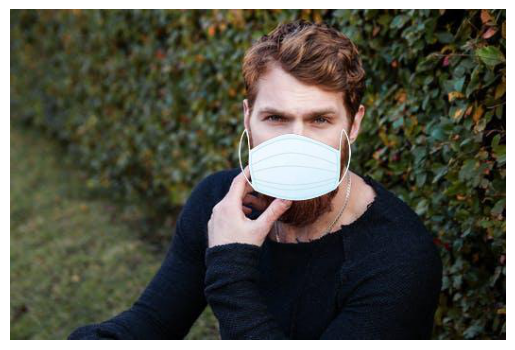

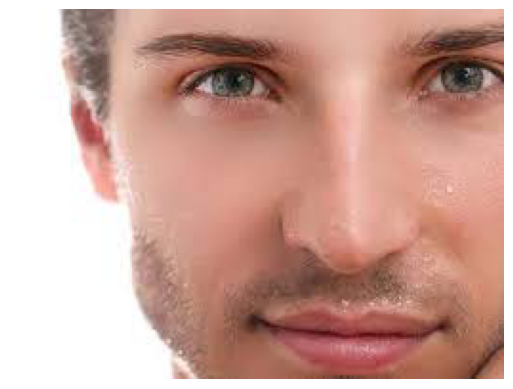

In [5]:
display_image(r"C:\Users\vivek\Downloads\data\with_mask\with_mask_1.jpg")

display_image(r"C:\Users\vivek\Downloads\data\without_mask\without_mask_995.jpg")


In [6]:
def process_images(directory, file_list): #processes images by resizing, converting to RGB and then to numpy array
    processed_data = []  
    for img_file in file_list:
        image_path = os.path.join(directory, img_file)  # creates the full path to the image file
        with Image.open(image_path) as image:  
            image = image.resize((64, 64))  
            image = image.convert("RGB")      
            image_array = np.array(image)     
            processed_data.append(image_array)  
    return processed_data

with_mask_path = r"C:\Users\vivek\Downloads\data\with_mask"
without_mask_path = r"C:\Users\vivek\Downloads\data\without_mask"


data_with_mask = process_images(with_mask_path, with_mask_files)
data_without_mask = process_images(without_mask_path, without_mask_files)

#combines the data from both categories into one list 
data = data_with_mask + data_without_mask
print("Processed data type:", type(data))  
print("Number of processed images:", len(data)) 



C:\Users\vivek\anaconda4\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Processed data type: <class 'list'>
Number of processed images: 7553


In [7]:
print(data[0])
print(type(data[0]))
data[0].shape

[[[ 48  56  34]
  [ 63  62  39]
  [ 51  54  28]
  ...
  [101  64  32]
  [ 40  42  27]
  [ 30  37  22]]

 [[ 51  59  37]
  [ 55  55  26]
  [ 42  40  19]
  ...
  [134  79  44]
  [ 58  48  22]
  [ 18  25  17]]

 [[ 51  57  42]
  [ 44  44  27]
  [ 31  32  13]
  ...
  [106  64  40]
  [ 65  54  29]
  [ 27  21  10]]

 ...

 [[ 82  90  56]
  [ 79  91  50]
  [ 71  83  48]
  ...
  [ 11  12  10]
  [ 19  21  13]
  [ 32  36  27]]

 [[ 71  80  43]
  [ 70  82  46]
  [ 64  78  50]
  ...
  [ 12  14   8]
  [  9   9   6]
  [ 25  25  20]]

 [[ 57  69  36]
  [ 59  65  42]
  [ 59  67  46]
  ...
  [ 23  20   7]
  [ 15  16  12]
  [ 15  11  10]]]
<class 'numpy.ndarray'>


(64, 64, 3)

In [8]:
#converting image list and label list to numpy array
x= np.array(data)
y = np.array(labels)
print(type(x))
print(type(y))
print(x.shape)
print(y.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(7553, 64, 64, 3)
(7553,)


## Train test split


In [9]:
def split_data(features, labels, test_size=0.2, random_state=2):
    return train_test_split(features, labels, test_size=test_size, random_state=random_state)

def scale_data(data): # scaling the feature data to range [0, 1].
    return (data / 255.0).astype(np.float32)

X_train, X_test, Y_train, Y_test = split_data(x, y)

X_train_scaled = scale_data(X_train)
X_test_scaled = scale_data(X_test)

print(x.shape, X_train.shape, X_test.shape)
print("First training example, post-scaling:")
print(X_train_scaled[0])


(7553, 64, 64, 3) (6042, 64, 64, 3) (1511, 64, 64, 3)
First training example, post-scaling:
[[[0.8352941  0.85490197 0.78039217]
  [0.7764706  0.7607843  0.7254902 ]
  [0.63529414 0.60784316 0.5882353 ]
  ...
  [0.72156864 0.7490196  0.7137255 ]
  [0.7411765  0.73333335 0.6862745 ]
  [0.67058825 0.69411767 0.57254905]]

 [[0.84705883 0.8392157  0.85882354]
  [0.8039216  0.7921569  0.7921569 ]
  [0.63529414 0.627451   0.5882353 ]
  ...
  [0.7490196  0.7529412  0.76862746]
  [0.7372549  0.72156864 0.7254902 ]
  [0.7411765  0.7137255  0.7058824 ]]

 [[0.8745098  0.85882354 0.827451  ]
  [0.84313726 0.84705883 0.8       ]
  [0.62352943 0.63529414 0.5921569 ]
  ...
  [0.7490196  0.7764706  0.75686276]
  [0.69803923 0.7294118  0.67058825]
  [0.7019608  0.7294118  0.6745098 ]]

 ...

 [[0.6431373  0.7372549  0.79607844]
  [0.6745098  0.7411765  0.84313726]
  [0.6745098  0.7294118  0.85882354]
  ...
  [0.40784314 0.4        0.27450982]
  [0.47843137 0.4627451  0.29411766]
  [0.49803922 0.45490

##  Convolutional Neural network

In [17]:
import tensorflow as tf
from tensorflow import keras

def build_model(input_shape, num_of_classes):
    model = keras.Sequential([
        keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=input_shape),
        keras.layers.MaxPool2D(pool_size=(2,2)),
        keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
        keras.layers.MaxPool2D(pool_size=(2,2)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(num_of_classes, activation='sigmoid')
    ])
    return model

def compile_and_train(model, X_train, Y_train, optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'], validation_split=0.2, epochs=5):
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    history = model.fit(X_train, Y_train, validation_split=validation_split, epochs=epochs)
    return history


In [18]:
#input shape and number of classes
input_shape = (64, 64, 3)
num_of_classes = 2

model = build_model(input_shape, num_of_classes)
history = compile_and_train(model, X_train_scaled, Y_train)


C:\Users\vivek\anaconda4\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step - acc: 0.6602 - loss: 0.6077 - val_acc: 0.8875 - val_loss: 0.2895
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - acc: 0.8723 - loss: 0.3212 - val_acc: 0.9123 - val_loss: 0.2366
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - acc: 0.8868 - loss: 0.2764 - val_acc: 0.9239 - val_loss: 0.2036
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - acc: 0.9043 - loss: 0.2366 - val_acc: 0.9404 - val_loss: 0.1816
Epoch 5/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - acc: 0.9173 - loss: 0.2082 - val_acc: 0.9371 - val_loss: 0.1816


## Model Evaluation

In [19]:
def evaluate_model(model, X_test, Y_test):
    loss, accuracy = model.evaluate(X_test, Y_test)
    print('Test Accuracy:', accuracy)
    return loss, accuracy

def plot_history(history):
    # plots the loss values
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='validation_loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

    #plots the accuracy values
    plt.figure(figsize=(8, 6))
    plt.plot(history.history['acc'], label='train_accuracy')
    plt.plot(history.history['val_acc'], label='validation_accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9296 - loss: 0.1771
Test Accuracy: 0.9291859865188599


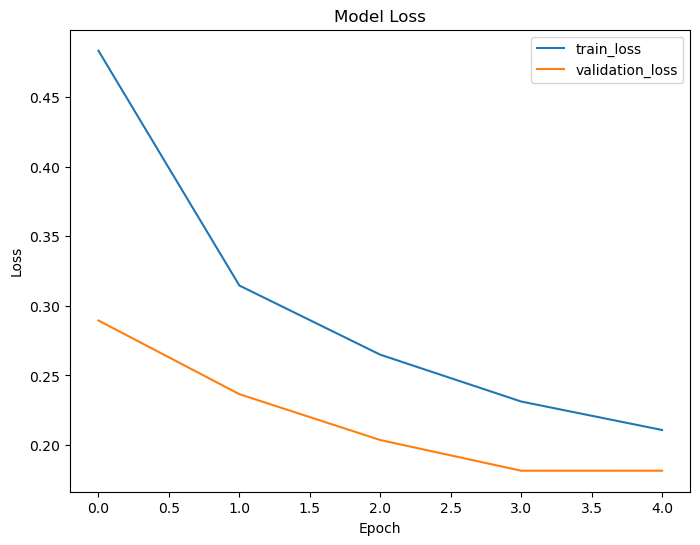

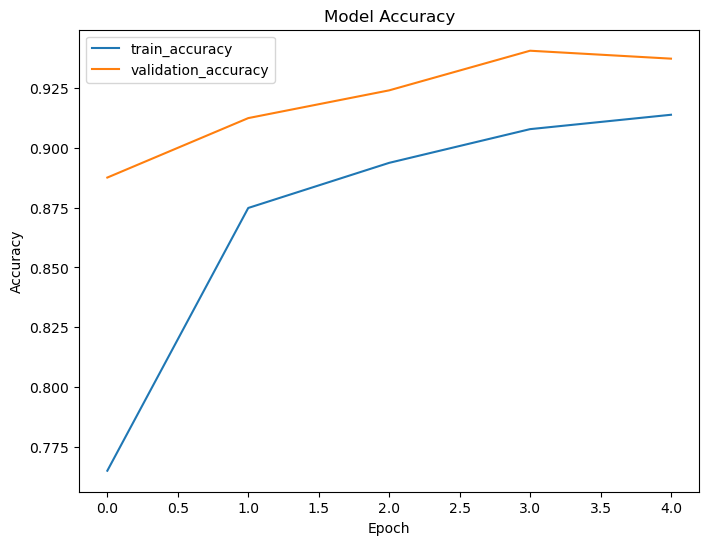

In [20]:
loss, accuracy = evaluate_model(model, X_test_scaled, Y_test)
plot_history(history)


## Predictive System

Path of the image to be predicted:  mask1.jpg


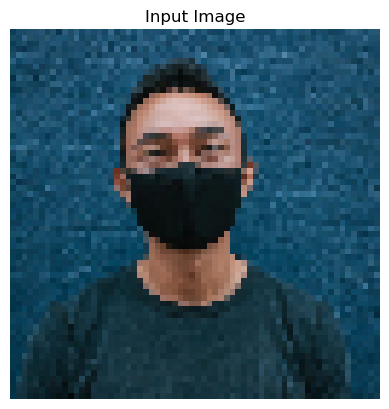

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
Prediction probabilities: [0.32288393 0.51865387]
Predicted label: 1
The person is wearing a mask.


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

def load_and_process_image(image_path, target_size=(64, 64)):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Could not open or find the image. Check the path.")
    
    image_resized = cv2.resize(image, target_size)
    image_scaled = image_resized / 255.0
    image_reshaped = np.reshape(image_scaled, [1] + list(target_size) + [3])

    # Display the image using matplotlib for higher quality
    plt.imshow(cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB))
    plt.title('Input Image')
    plt.axis('off') 
    plt.show()
    
    return image_reshaped

def predict_image(model, image):
    """Makes a prediction on a preprocessed image and print the result, including probabilitie."""
    prediction = model.predict(image)
    pred_label = np.argmax(prediction)
    pred_probabilities = prediction[0]
    
    print(f"Prediction probabilities: {pred_probabilities}")
    print(f"Predicted label: {pred_label}")
    
    if pred_label == 1:
        print("The person is wearing a mask.")
    else:
        print("The person is not wearing a mask.")
    
    return pred_label


input_image_path = input('Path of the image to be predicted: ')

try:
    processed_image = load_and_process_image(input_image_path)
    predicted_label = predict_image(model, processed_image)
except Exception as e:
    print(e)


In [22]:
import os
print(os.getcwd())


C:\Users\vivek\CI642


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


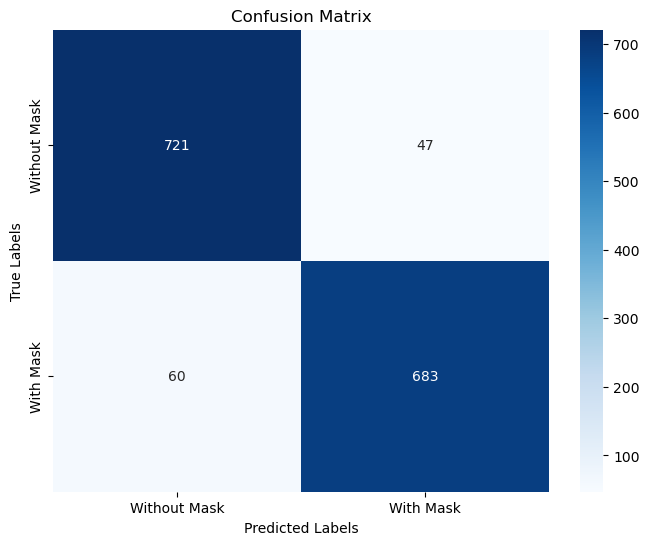

Classification Report:
              precision    recall  f1-score   support

Without Mask       0.92      0.94      0.93       768
   With Mask       0.94      0.92      0.93       743

    accuracy                           0.93      1511
   macro avg       0.93      0.93      0.93      1511
weighted avg       0.93      0.93      0.93      1511



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# predicts the labels for the test set
y_pred = np.argmax(model.predict(X_test_scaled), axis=1)

# computes the confusion matrix
conf_matrix = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Without Mask', 'With Mask'], yticklabels=['Without Mask', 'With Mask'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


class_report = classification_report(Y_test, y_pred, target_names=['Without Mask', 'With Mask'])
print("Classification Report:")
print(class_report)
